# Tabular Modeling

## Data Loading/Preparations

In [1]:
import pandas as pd
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("tabular_data_modeling").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/18 02:50:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Loading cleaned training/testing sets from tabular_data_cleaning.ipynb
hdfs_path = "hdfs://localhost:9000/user/jj/final_proj/"

train_df = spark.read.parquet(hdfs_path + "train.parquet")
test_df = spark.read.parquet(hdfs_path + "test.parquet")

25/04/18 02:50:42 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
                                                                                

In [3]:
train_df.show(5)

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,2,3,11],...|     1|
|(15,[0,1,3,9,14],...|     0|
|(15,[0,1,2,3,9,14...|     1|
|(15,[0,1,4,10],[4...|     1|
|(15,[0,1,3,12],[2...|     0|
+--------------------+------+
only showing top 5 rows



## Initial Modeling (Untuned Models)

In [4]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [5]:
from pyspark.sql import Row

def append_classification_report(results_df, predictions, model_name):
    """
    Appends a new row of classification metrics to an existing Spark DataFrame.
    
    Parameters:
        results_df (DataFrame): Spark DataFrame holding previous model metrics
        predictions (DataFrame): Predictions output from a model
        model_name (str): Name of the model for reporting
        
    Returns:
        DataFrame: Updated Spark DataFrame with the new model's metrics appended
    """

    # Evaluators
    auc_eval = BinaryClassificationEvaluator(labelCol="Cancer", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    acc_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="accuracy")
    f1_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="f1")
    prec_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="precisionByLabel")
    rec_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="recallByLabel")

    # Metrics
    auc = auc_eval.evaluate(predictions)
    acc = acc_eval.evaluate(predictions)
    f1 = f1_eval.evaluate(predictions)
    prec = prec_eval.evaluate(predictions)
    rec = rec_eval.evaluate(predictions)

    # Create a new row
    row = Row("Model", "AUC", "Accuracy", "F1", "Precision", "Recall")
    new_row = predictions.sparkSession.createDataFrame([row(model_name, auc, acc, f1, prec, rec)])

    # Append to existing results_df
    updated_df = results_df.unionByName(new_row)

    return updated_df


In [6]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Creating a results dataframe for easy comparison
schema = StructType([
    StructField("Model", StringType(), True),
    StructField("AUC", DoubleType(), True),
    StructField("Accuracy", DoubleType(), True),
    StructField("F1", DoubleType(), True),
    StructField("Precision", DoubleType(), True),
    StructField("Recall", DoubleType(), True)
])

results_df = spark.createDataFrame([], schema)

### Model 1: Logistic Regression

In [7]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol='Cancer', featuresCol='features')

lr_model = lr.fit(train_df)

predictions = lr_model.transform(test_df)

25/04/18 02:51:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/04/18 02:51:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

In [8]:
# Evaluation
lr_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
lr_auc = lr_binary.evaluate(predictions)

lr_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
lr_acc = lr_multi_acc.evaluate(predictions)

lr_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
lr_f1 = lr_multi_f1.evaluate(predictions)

print("Logistic Regression Results:")
print("Area Under ROC - " + str(lr_auc))
print("Accuracy - " + str(lr_acc))
print("F1 - " + str(lr_f1))

[Stage 33:>                                                         (0 + 2) / 2]

Logistic Regression Results:
Area Under ROC - 0.8197252150550018
Accuracy - 0.7251747329552948
F1 - 0.7739803843772705


In [9]:
results_df = append_classification_report(results_df, predictions, "Logistic Regression")

### Model 2: Random Forest

In [10]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol='Cancer', featuresCol='features')

rf_model = rf.fit(train_df)

predictions = rf_model.transform(test_df)

In [11]:
# Evaluation
rf_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
rf_auc = rf_binary.evaluate(predictions)

rf_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
rf_acc = rf_multi_acc.evaluate(predictions)

rf_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
rf_f1 = rf_multi_f1.evaluate(predictions)

print("Random Forest Results:")
print("Area Under ROC - " + str(rf_auc))
print("Accuracy - " + str(rf_acc))
print("F1 - " + str(rf_f1))

Random Forest Results:
Area Under ROC - 0.8156540266707955
Accuracy - 0.7156798101015429
F1 - 0.7668100355963462


In [12]:
results_df = append_classification_report(results_df, predictions, "Random Forest")

### Model 3: Gradient Boosted Trees

In [13]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(labelCol='Cancer', featuresCol='features')

gbt_model = gbt.fit(train_df)

predictions = gbt_model.transform(test_df)

In [14]:
# Evaluation
gbt_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
gbt_auc = gbt_binary.evaluate(predictions)

gbt_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
gbt_acc = gbt_multi_acc.evaluate(predictions)

gbt_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
gbt_f1 = gbt_multi_f1.evaluate(predictions)

print("Gradient Boosted Trees Results:")
print("Area Under ROC - " + str(gbt_auc))
print("Accuracy - " + str(gbt_acc))
print("F1 - " + str(gbt_f1))

Gradient Boosted Trees Results:
Area Under ROC - 0.8168490963609611
Accuracy - 0.71132797046024
F1 - 0.7634088619709194


In [15]:
results_df = append_classification_report(results_df, predictions, "GBT")

### Model 4: Naive Bayes

In [16]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(labelCol='Cancer', featuresCol='features')

nb_model = nb.fit(train_df)

predictions = nb_model.transform(test_df)

In [17]:
# Evaluation
nb_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
nb_auc = nb_binary.evaluate(predictions)

nb_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
nb_acc = nb_multi_acc.evaluate(predictions)

nb_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
nb_f1 = nb_multi_f1.evaluate(predictions)

print("Naive Bayes Results:")
print("Area Under ROC - " + str(nb_auc))
print("Accuracy - " + str(nb_acc))
print("F1 - " + str(nb_f1))

Naive Bayes Results:
Area Under ROC - 0.43131065150871545
Accuracy - 0.6871950415402874
F1 - 0.7439943131537241


In [18]:
results_df = append_classification_report(results_df, predictions, "Naive Bayes")

### Model 5: Multilayer Perceptron

In [19]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

layers = [len(train_df.select("features").first()[0]), 5, 2]

mlpc = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='Cancer',
    layers=layers,
    seed=101
)

mlpc_model = mlpc.fit(train_df)

predictions = mlpc_model.transform(test_df)

In [20]:
# Evaluation
mlpc_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
mlpc_auc = mlpc_binary.evaluate(predictions)

mlpc_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
mlpc_acc = mlpc_multi_acc.evaluate(predictions)

mlpc_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
mlpc_f1 = mlpc_multi_f1.evaluate(predictions)

print("Multilayer Perceptron Results:")
print("Area Under ROC - " + str(mlpc_auc))
print("Accuracy - " + str(mlpc_acc))
print("F1 - " + str(mlpc_f1))

Multilayer Perceptron Results:
Area Under ROC - 0.8131735617488418
Accuracy - 0.7134379533166293
F1 - 0.7651381713397933


In [21]:
results_df = append_classification_report(results_df, predictions, "Multilayer Perceptron")

### Model 6: SVM

In [22]:
from pyspark.ml.classification import LinearSVC

svm = LinearSVC(labelCol='Cancer', featuresCol='features')

svm_model = svm.fit(train_df)

predictions = svm_model.transform(test_df)

In [23]:
# Evaluation
svm_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
svm_auc = svm_binary.evaluate(predictions)

svm_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
svm_acc = svm_multi_acc.evaluate(predictions)

svm_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
svm_f1 = svm_multi_f1.evaluate(predictions)

print("SVM Results:")
print("Area Under ROC - " + str(svm_auc))
print("Accuracy - " + str(svm_acc))
print("F1 - " + str(svm_f1))

SVM Results:
Area Under ROC - 0.8192704486215054
Accuracy - 0.71132797046024
F1 - 0.7634904970541858


In [24]:
results_df = append_classification_report(results_df, predictions, "SVM")

### Bonus: Logistic Regression with classWeightCol

In [25]:
from pyspark.sql.functions import when, col

weighted_df = train_df.withColumn("classWeightCol", when(col("Cancer") == 1, 2.0).otherwise(1.0))

In [26]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol='Cancer', featuresCol='features', weightCol='classWeightCol')

lr_model = lr.fit(weighted_df)

predictions = lr_model.transform(test_df)

In [27]:
# Evaluation
lr_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
lr_auc = lr_binary.evaluate(predictions)

lr_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
lr_acc = lr_multi_acc.evaluate(predictions)

lr_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
lr_f1 = lr_multi_f1.evaluate(predictions)

print("Weighted Logistic Regression Results:")
print("Area Under ROC - " + str(lr_auc))
print("Accuracy - " + str(lr_acc))
print("F1 - " + str(lr_f1))

Weighted Logistic Regression Results:
Area Under ROC - 0.8193486551956699
Accuracy - 0.5892127126467097
F1 - 0.661826013736026


### Result Evaluation

In [31]:
results_df.orderBy('F1').show()

+--------------------+------------------+------------------+------------------+------------------+------------------+
|               Model|               AUC|          Accuracy|                F1|         Precision|            Recall|
+--------------------+------------------+------------------+------------------+------------------+------------------+
|         Naive Bayes|0.4313139646077321|0.6871950415402874|0.7439943131537241|0.9520846297448662|0.6819194770465012|
|                 GBT|0.8168466551301072|  0.71132797046024|0.7634088619709194| 0.964227309893704|0.7007874015748031|
|                 SVM| 0.819271669236934|  0.71132797046024|0.7634904970541858|0.9657506152584086| 0.699598870895855|
|Multilayer Percep...|0.8131746079906366|0.7134379533166293|0.7651381713397933|0.9658626328699919|0.7019759322537513|
|       Random Forest|0.8156540266707957|0.7156798101015429|0.7668100355963462|0.9646556977452773|0.7055415242905958|
| Logistic Regression|0.8197219019559843|0.7251747329552

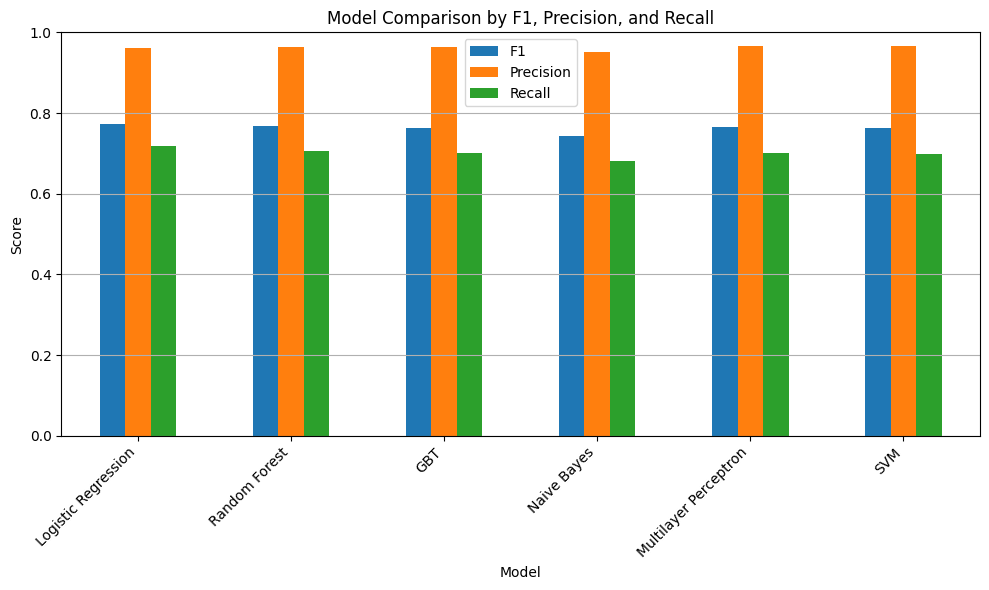

In [29]:
# Convert Spark DataFrame to Pandas
pandas_df = results_df.toPandas()

# Plotting F1, Recall, and AUC
import matplotlib.pyplot as plt

metrics_to_plot = ["F1", "Precision", "Recall"]
pandas_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison by F1, Precision, and Recall")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


## Model Tuning

In [30]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [56]:
# Tuned Results Dataframe
schema = StructType([
    StructField("Model", StringType(), True),
    StructField("AUC", DoubleType(), True),
    StructField("Accuracy", DoubleType(), True),
    StructField("F1", DoubleType(), True),
    StructField("Precision", DoubleType(), True),
    StructField("Recall", DoubleType(), True)
])

tuned_results_df = spark.createDataFrame([], schema)

### Model 1: Random Forest

In [53]:
rf = RandomForestClassifier(labelCol='Cancer', featuresCol='features', seed=101)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [50, 100]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .addGrid(rf.minInstancesPerNode, [1, 5]) \
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)

25/04/18 03:42:27 WARN DAGScheduler: Broadcasting large task binary with size 1248.6 KiB
25/04/18 03:42:28 WARN DAGScheduler: Broadcasting large task binary with size 1862.6 KiB
25/04/18 03:42:29 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/04/18 03:42:31 WARN DAGScheduler: Broadcasting large task binary with size 1580.4 KiB
25/04/18 03:42:35 WARN DAGScheduler: Broadcasting large task binary with size 1248.6 KiB
25/04/18 03:42:37 WARN DAGScheduler: Broadcasting large task binary with size 1862.6 KiB
25/04/18 03:42:39 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/04/18 03:42:41 WARN DAGScheduler: Broadcasting large task binary with size 1580.4 KiB
25/04/18 03:42:46 WARN DAGScheduler: Broadcasting large task binary with size 1146.5 KiB
25/04/18 03:42:47 WARN DAGScheduler: Broadcasting large task binary with size 1628.8 KiB
25/04/18 03:42:49 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/04/18 03:42:51 WARN DAGSche

In [54]:
best_rf_model = cv_model.bestModel
rf_predictions = best_rf_model.transform(test_df)

f1_score = evaluator.evaluate(rf_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

25/04/18 03:50:08 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
[Stage 8620:>                                                       (0 + 2) / 2]

Best F1 Score on Test Data: 0.7827


In [55]:
best_params = best_rf_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

bootstrap: True
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: sqrt
featuresCol: features
impurity: gini
labelCol: Cancer
leafCol: 
maxBins: 32
maxDepth: 10
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
numTrees: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: 101
subsamplingRate: 1.0


In [57]:
tuned_results_df = append_classification_report(tuned_results_df, rf_predictions, "Random Forest")

25/04/18 03:53:00 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 03:53:03 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/18 03:53:06 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/18 03:53:08 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/18 03:53:10 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
                                                                                

In [ ]:
# Best params:
# Numtrees: 100
# Maxdepth: 10
# MinINstance: 1
# SubsetStrat: sqrt

### Model 2: Logistic Regression

In [60]:
lr = LogisticRegression(labelCol='Cancer', featuresCol='features')

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .addGrid(lr.maxIter, [50, 100]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)

In [61]:
best_lr_model = cv_model.bestModel
lr_predictions = best_lr_model.transform(test_df)

f1_score = evaluator.evaluate(lr_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

Best F1 Score on Test Data: 0.7720


In [62]:
best_params = best_lr_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

aggregationDepth: 2
elasticNetParam: 0.5
family: auto
featuresCol: features
fitIntercept: True
labelCol: Cancer
maxBlockSizeInMB: 0.0
maxIter: 50
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
regParam: 0.01
standardization: True
threshold: 0.5
tol: 1e-06


In [63]:
tuned_results_df = append_classification_report(tuned_results_df, lr_predictions, "Logistic Regression")

In [ ]:
# Best params:
# regParam: 0.01
# elastic: 0.5
# maxIter: 50

### Model 3: Gradient Boosted Trees

In [68]:
gbt = GBTClassifier(labelCol='Cancer', featuresCol='features')

paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxIter, [20, 50, 100]) \
    .addGrid(gbt.maxDepth, [3, 5, 7]) \
    .addGrid(gbt.stepSize, [0.05, 0.1]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)

25/04/18 04:05:27 WARN DAGScheduler: Broadcasting large task binary with size 1000.8 KiB
25/04/18 04:05:27 WARN DAGScheduler: Broadcasting large task binary with size 1001.6 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1004.0 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1008.7 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1018.2 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1021.9 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1022.4 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1023.4 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1024.1 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1026.5 KiB
25/04/18 04:05:30 WARN DAGScheduler: Broadcasting large task binary with size 1031.2 KiB
25/04/18 04:05:30 WAR

In [69]:
best_gbt_model = cv_model.bestModel
gbt_predictions = best_gbt_model.transform(test_df)

f1_score = evaluator.evaluate(gbt_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

25/04/18 04:40:40 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
[Stage 41894:>                                                      (0 + 2) / 2]

Best F1 Score on Test Data: 0.7830


In [70]:
best_params = best_gbt_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: all
featuresCol: features
impurity: variance
labelCol: Cancer
leafCol: 
lossType: logistic
maxBins: 32
maxDepth: 7
maxIter: 100
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: -516051250147499693
stepSize: 0.1
subsamplingRate: 1.0
validationTol: 0.01


In [71]:
tuned_results_df = append_classification_report(tuned_results_df, gbt_predictions, "GBT")

25/04/18 04:41:41 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:44 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:46 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:48 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:49 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
                                                                                

### Model 4: Multilayer Perceptron

In [76]:
input_size = len(train_df.select("features").first()[0])  # size of the vector
output_size = 2  # For binary classification

# Define several network topologies
layer_configs = [
    [input_size, 5, output_size],               # 1 hidden layer
    [input_size, 10, 5, output_size],           # 2 hidden layers
    [input_size, 15, 10, 5, output_size],       # deeper network
]


mlp = MultilayerPerceptronClassifier(labelCol="Cancer", featuresCol="features", seed=101)

paramGrid = ParamGridBuilder() \
    .addGrid(mlp.layers, layer_configs) \
    .addGrid(mlp.stepSize, [0.01, 0.1]) \
    .addGrid(mlp.maxIter, [100, 200]) \
    .addGrid(mlp.blockSize, [64, 128]) \
    .build()

cv = CrossValidator(
    estimator=mlp,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)


25/04/18 04:59:12 WARN BlockManager: Asked to remove block broadcast_86116_piece0, which does not exist


In [77]:
best_mlp_model = cv_model.bestModel
mlp_predictions = best_mlp_model.transform(test_df)

f1_score = evaluator.evaluate(mlp_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

Best F1 Score on Test Data: 0.7627


In [78]:
best_params = best_mlp_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

blockSize: 64
featuresCol: features
labelCol: Cancer
maxIter: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: 101
solver: l-bfgs
stepSize: 0.01
tol: 1e-06
layers: [15, 15, 10, 5, 2]


In [79]:
tuned_results_df = append_classification_report(tuned_results_df, mlp_predictions, "MLP")

### Tuned Result Evaluation

In [80]:
tuned_results_df.orderBy('F1', ascending=False).show()

+-------------------+------------------+------------------+------------------+------------------+------------------+
|              Model|               AUC|          Accuracy|                F1|         Precision|            Recall|
+-------------------+------------------+------------------+------------------+------------------+------------------+
|                GBT|0.7779411077468632|0.7391533693788738|0.7830357358296582|0.9472990777338604| 0.747734363393255|
|      Random Forest|0.8173134533442434|0.7369115125939601|0.7826667681598627|0.9592707525213343|0.7348090922596939|
|Logistic Regression|0.8191071477146937|0.7225372543848081| 0.771996612738761|0.9629777866720032|0.7149012033873124|
|                MLP|0.8212222998766141|0.7102729790320453|0.7626853299453413| 0.966077302631579|0.6981132075471698|
+-------------------+------------------+------------------+------------------+------------------+------------------+

